# SeaAlert - EDA: Synthetic Dataset Analysis

Exploratory Data Analysis for the synthetic maritime message dataset.

**Run this after:** Notebook 01 (Generate Synthetic Dataset)

## Cell 0 - Setup

In [15]:
# Mount Google Drive (Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# Install dependencies
!pip install -q pandas numpy matplotlib seaborn wordcloud

# Imports
import os
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Project directory
if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/SeaAlert")
else:
    PROJECT_DIR = Path(".").resolve().parent

RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/SeaAlert


## Cell 1 - Load Dataset

In [16]:
# Load dataset
DATASET_PATH = PROJECT_DIR / "data" / "processed" / "02seaalert.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}. Run notebook 01 first.")

df = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (1872, 16)

Columns: ['idx', 'text', 'label', 'style', 'scenario_type', 'has_codeword', 'codeword', 'text_masked', 'vessel', 'call_sign', 'mmsi', 'location', 'weather', 'pob', 'nature', 'injury']

Data types:
idx               int64
text             object
label            object
style            object
scenario_type    object
has_codeword       bool
codeword         object
text_masked      object
vessel           object
call_sign        object
mmsi             object
location         object
weather          object
pob              object
nature           object
injury           object
dtype: object


In [17]:
# Basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal samples: {len(df)}")
print(f"\nMissing values:")
missing = df.isnull().sum()
for col, count in missing[missing > 0].items():
    print(f"  {col}: {count} ({100*count/len(df):.1f}%)")

# Sample rows
print("\nSample rows:")
df.head(3)

DATASET OVERVIEW

Total samples: 1872

Missing values:
  call_sign: 576 (30.8%)
  mmsi: 866 (46.3%)
  weather: 13 (0.7%)
  pob: 178 (9.5%)
  nature: 130 (6.9%)
  injury: 674 (36.0%)

Sample rows:


,idx,text,label,style,scenario_type,has_codeword,codeword,text_masked,vessel,call_sign,mmsi,location,weather,pob,nature,injury
0,0,"MAYDAY, MAYDAY, MAYDAY. This is the fishing ve...",Distress,formal,nav_hazard,True,MAYDAY,"[SIGNAL], [SIGNAL], [SIGNAL]. This is the fish...",Ocean Hunter,WXYZ123,123456789,"37 degrees 45 minutes North, 122 degrees 30 mi...",overcast with a light swell,6,navigation hazard,no injuries reported
1,1,"This is the vessel Ocean Explorer, call sign A...",Safety,formal,medical_issue,False,NONE,"This is the vessel Ocean Explorer, call sign A...",Ocean Explorer,ABCD123,123456789,"34 degrees 15 minutes North, 120 degrees 45 mi...",clear with calm seas,15,medical issue,severe laceration to the arm
2,2,"SECURITE, SECURITE. This is the fishing vessel...",Safety,third_party,steering_failure,True,SECURITE,"[SIGNAL], [SIGNAL]. This is the fishing vessel...",Ocean's Bounty,WZ1234,123456789,"34°12.5'N, 118°28.9'W","Calm, 5 knots from the west",5,steering failure,none


## Cell 2 - Label Distribution

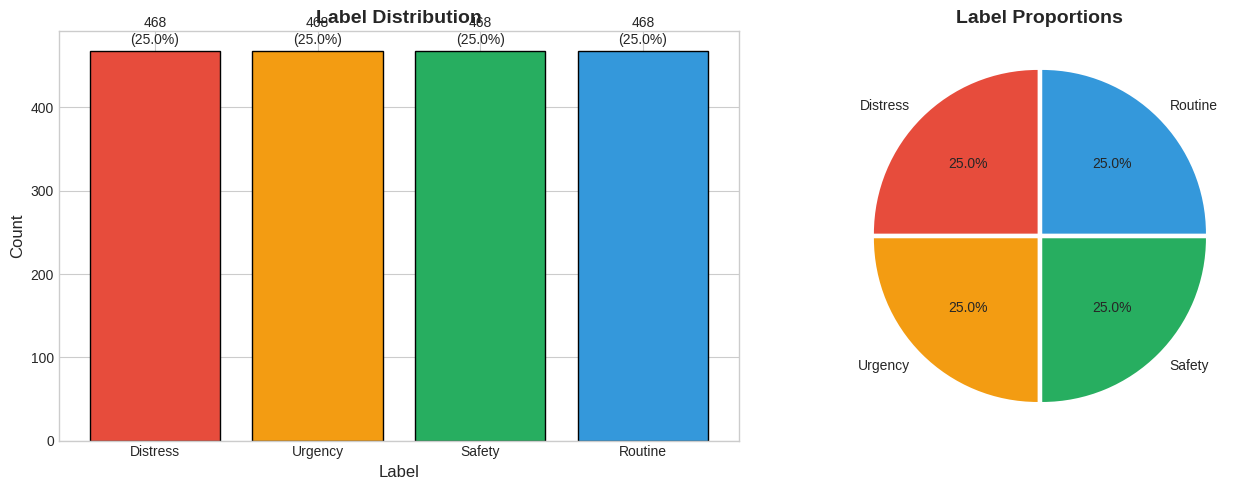

Label Statistics:
  Most common: Distress (468)
  Least common: Distress (468)
  Balance ratio: 1.00


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label counts
label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']  # Distress, Urgency, Safety, Routine
label_order = ['Distress', 'Urgency', 'Safety', 'Routine']
label_counts = label_counts.reindex(label_order)

# Bar chart
ax1 = axes[0]
bars = ax1.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('Label', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Label Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({100*count/len(df):.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
ax2 = axes[1]
ax2.pie(label_counts.values, labels=label_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90, explode=[0.02]*4)
ax2.set_title('Label Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("Label Statistics:")
print(f"  Most common: {label_counts.idxmax()} ({label_counts.max()})")
print(f"  Least common: {label_counts.idxmin()} ({label_counts.min()})")
print(f"  Balance ratio: {label_counts.min()/label_counts.max():.2f}")

## Cell 3 - Style & Scenario Distribution

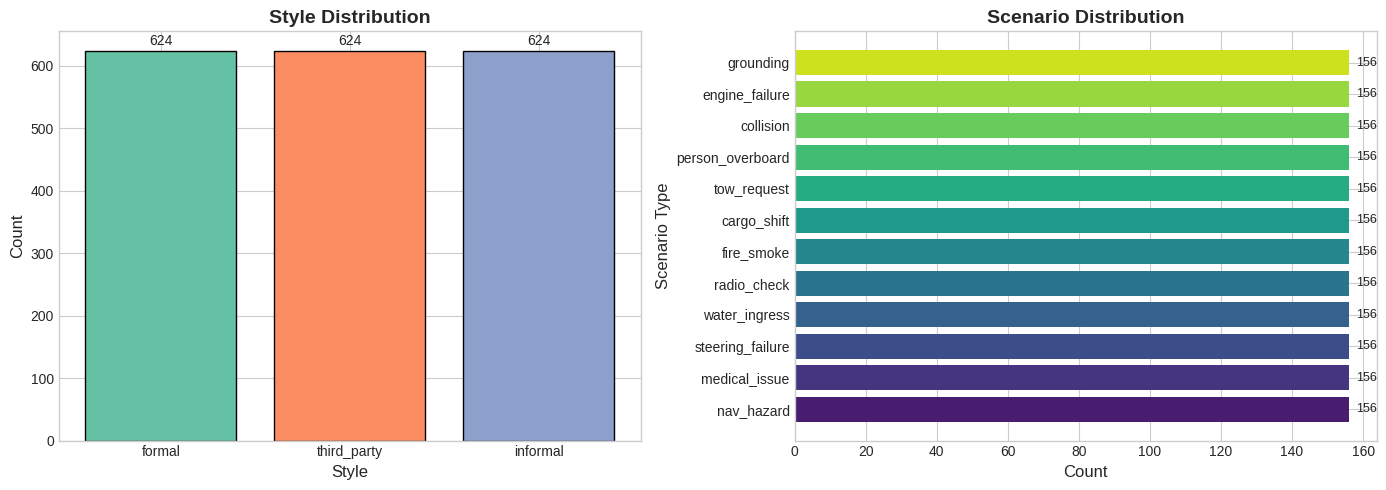

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Style distribution
ax1 = axes[0]
style_counts = df['style'].value_counts()
bars = ax1.bar(style_counts.index, style_counts.values, color=sns.color_palette('Set2', 3), edgecolor='black')
ax1.set_xlabel('Style', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Style Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, style_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)

# Scenario distribution
ax2 = axes[1]
scenario_counts = df['scenario_type'].value_counts()
bars = ax2.barh(scenario_counts.index, scenario_counts.values, color=sns.color_palette('viridis', len(scenario_counts)))
ax2.set_xlabel('Count', fontsize=12)
ax2.set_ylabel('Scenario Type', fontsize=12)
ax2.set_title('Scenario Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, scenario_counts.values):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{count}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_style_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

Label x Style Cross-tabulation:
style     formal  informal  third_party
label                                  
Distress     156       156          156
Routine      156       156          156
Safety       156       156          156
Urgency      156       156          156


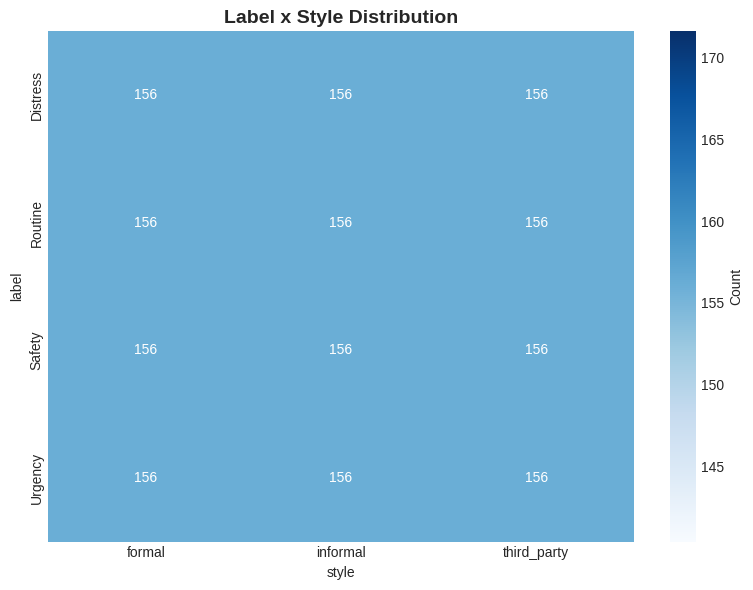

In [6]:
# Cross-tabulation: Label x Style
print("Label x Style Cross-tabulation:")
cross_tab = pd.crosstab(df['label'], df['style'])
print(cross_tab)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Label x Style Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_label_style_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 4 - Text Length Analysis

/tmp/ipython-input-2419721782.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ordered, x='label', y='text_len_words', ax=ax3, palette=colors, order=label_order)
/tmp/ipython-input-2419721782.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='style', y='text_len_words', ax=ax4, palette='Set2')


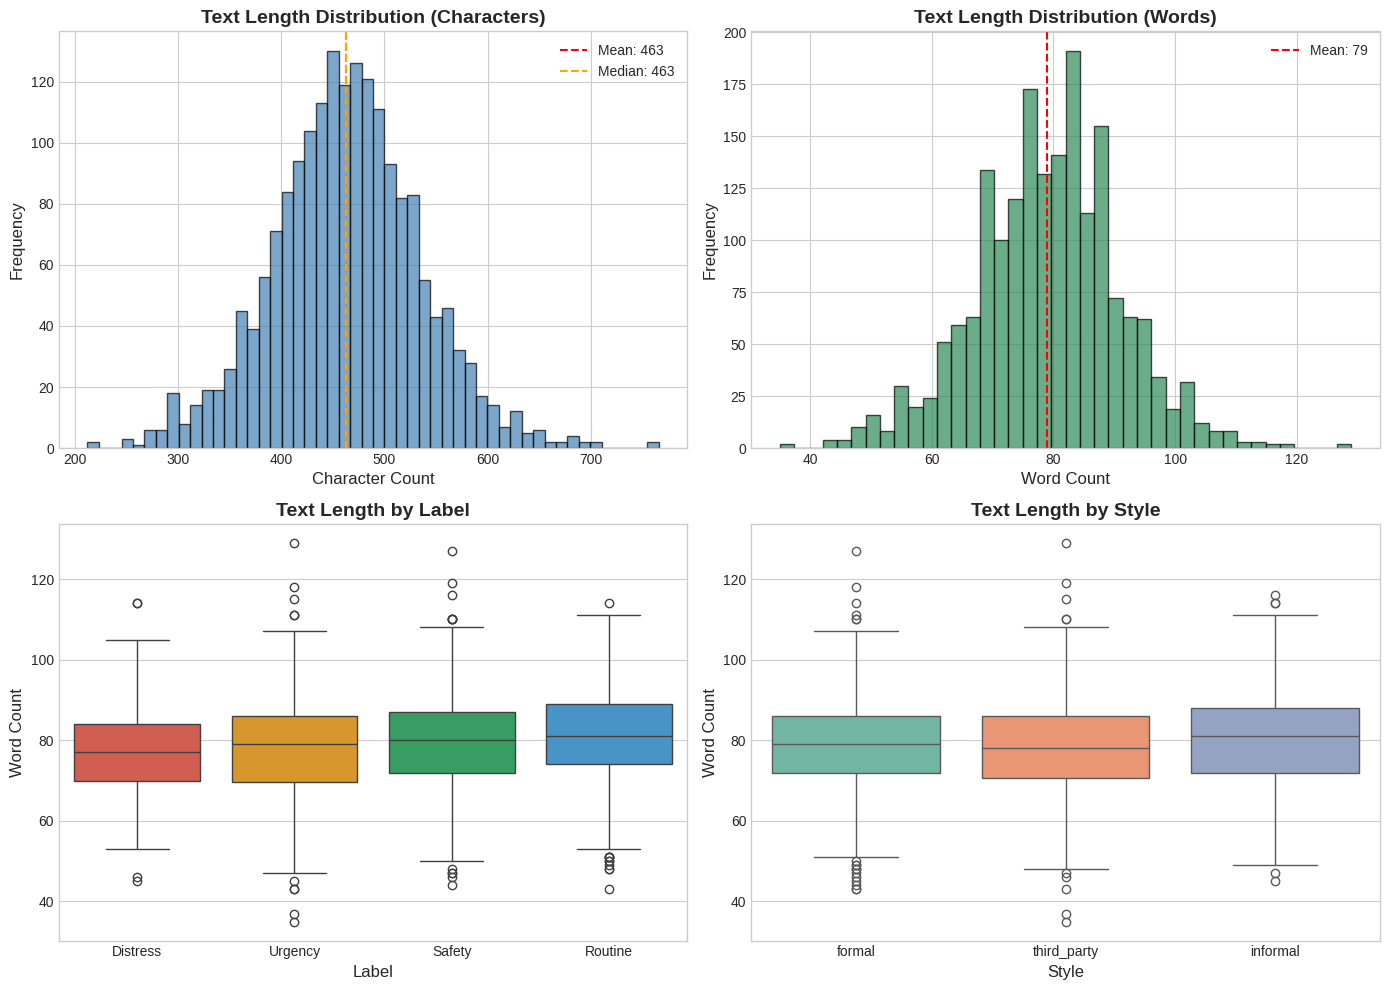


Text Length Statistics:
  Characters: min=212, max=766, mean=463.1
  Words: min=35, max=129, mean=79.0


In [7]:
# Calculate text lengths
df['text_len_chars'] = df['text'].apply(lambda x: len(str(x)))
df['text_len_words'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Character length distribution
ax1 = axes[0, 0]
ax1.hist(df['text_len_chars'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['text_len_chars'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_len_chars"].mean():.0f}')
ax1.axvline(df['text_len_chars'].median(), color='orange', linestyle='--', label=f'Median: {df["text_len_chars"].median():.0f}')
ax1.set_xlabel('Character Count', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Text Length Distribution (Characters)', fontsize=14, fontweight='bold')
ax1.legend()

# Word length distribution
ax2 = axes[0, 1]
ax2.hist(df['text_len_words'], bins=40, color='seagreen', edgecolor='black', alpha=0.7)
ax2.axvline(df['text_len_words'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_len_words"].mean():.0f}')
ax2.set_xlabel('Word Count', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Text Length Distribution (Words)', fontsize=14, fontweight='bold')
ax2.legend()

# Box plot by label
ax3 = axes[1, 0]
label_order = ['Distress', 'Urgency', 'Safety', 'Routine']
df_ordered = df.copy()
df_ordered['label'] = pd.Categorical(df_ordered['label'], categories=label_order, ordered=True)
sns.boxplot(data=df_ordered, x='label', y='text_len_words', ax=ax3, palette=colors, order=label_order)
ax3.set_xlabel('Label', fontsize=12)
ax3.set_ylabel('Word Count', fontsize=12)
ax3.set_title('Text Length by Label', fontsize=14, fontweight='bold')

# Box plot by style
ax4 = axes[1, 1]
sns.boxplot(data=df, x='style', y='text_len_words', ax=ax4, palette='Set2')
ax4.set_xlabel('Style', fontsize=12)
ax4.set_ylabel('Word Count', fontsize=12)
ax4.set_title('Text Length by Style', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("\nText Length Statistics:")
print(f"  Characters: min={df['text_len_chars'].min()}, max={df['text_len_chars'].max()}, mean={df['text_len_chars'].mean():.1f}")
print(f"  Words: min={df['text_len_words'].min()}, max={df['text_len_words'].max()}, mean={df['text_len_words'].mean():.1f}")

## Cell 5 - Codeword Analysis

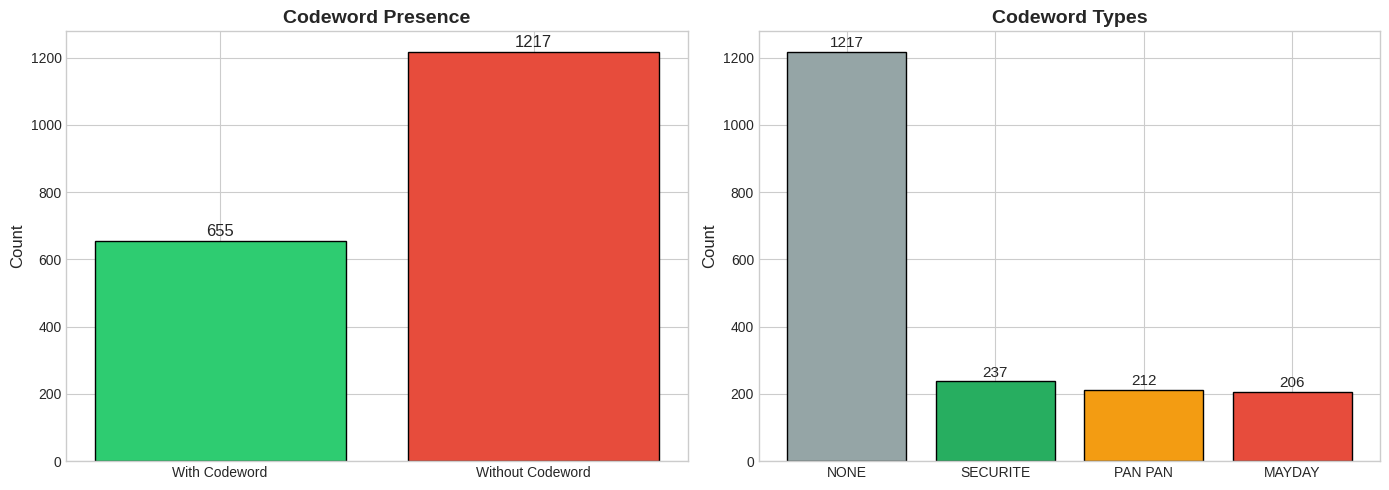


Codeword Distribution by Label:
has_codeword  False  True   All
label                          
Distress        263   205   468
Routine         468     0   468
Safety          231   237   468
Urgency         255   213   468
All            1217   655  1872


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Codeword presence
ax1 = axes[0]
cw_counts = df['has_codeword'].value_counts()
bars = ax1.bar(['With Codeword', 'Without Codeword'],
               [cw_counts.get(True, 0), cw_counts.get(False, 0)],
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Codeword Presence', fontsize=14, fontweight='bold')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=12)

# Codeword types
ax2 = axes[1]
codeword_counts = df['codeword'].value_counts()
cw_colors = {'MAYDAY': '#e74c3c', 'PAN PAN': '#f39c12', 'SECURITE': '#27ae60', 'NONE': '#95a5a6'}
bars = ax2.bar(codeword_counts.index, codeword_counts.values,
               color=[cw_colors.get(cw, 'gray') for cw in codeword_counts.index], edgecolor='black')
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Codeword Types', fontsize=14, fontweight='bold')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_codewords.png', dpi=150, bbox_inches='tight')
plt.show()

# Codeword by label
print("\nCodeword Distribution by Label:")
cw_by_label = pd.crosstab(df['label'], df['has_codeword'], margins=True)
print(cw_by_label)

## Cell 6 - Word Frequency & Word Clouds

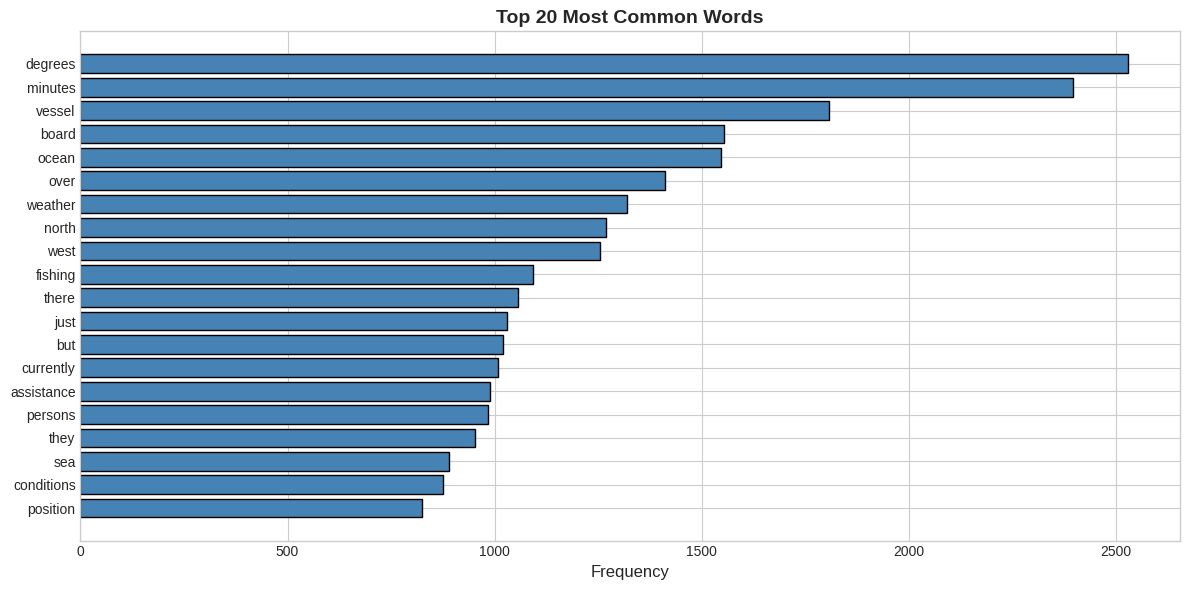

In [9]:
# Common words
all_text = ' '.join(df['text'].astype(str).tolist())
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text.lower())
word_counts = Counter(words)

# Stop words to exclude
stop_words = {'the', 'this', 'and', 'for', 'are', 'with', 'has', 'have', 'our', 'your', 'that', 'from', 'all'}
filtered_counts = {w: c for w, c in word_counts.items() if w not in stop_words}

# Top 20 words
top_words = sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True)[:20]

plt.figure(figsize=(12, 6))
words_df = pd.DataFrame(top_words, columns=['Word', 'Count'])
bars = plt.barh(words_df['Word'][::-1], words_df['Count'][::-1], color='steelblue', edgecolor='black')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Common Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

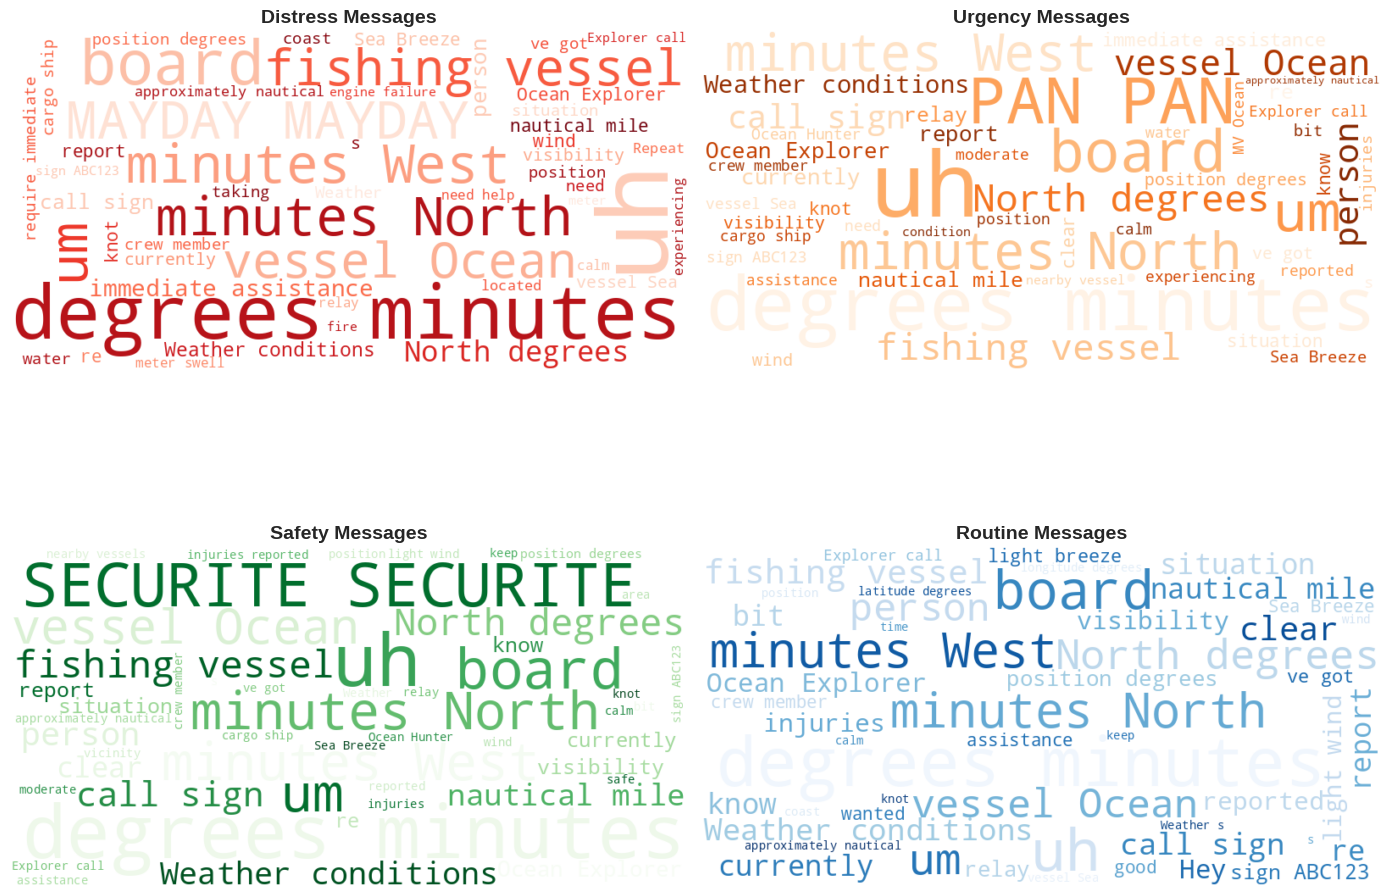

In [10]:
# Word clouds by label
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
labels = ['Distress', 'Urgency', 'Safety', 'Routine']
colors_map = {'Distress': 'Reds', 'Urgency': 'Oranges', 'Safety': 'Greens', 'Routine': 'Blues'}

for ax, label in zip(axes.flat, labels):
    label_text = ' '.join(df[df['label'] == label]['text'].astype(str).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                         colormap=colors_map[label], max_words=50).generate(label_text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{label} Messages', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 - Duplicate & Quality Analysis

In [11]:
# Duplicate analysis
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

# Exact duplicates
exact_dups = df['text'].duplicated().sum()
print(f"\nExact duplicates: {exact_dups} ({100*exact_dups/len(df):.2f}%)")

if exact_dups > 0:
    print("\nDuplicated texts (first 3):")
    dup_texts = df[df['text'].duplicated(keep=False)]['text'].unique()[:3]
    for i, text in enumerate(dup_texts, 1):
        print(f"  {i}. {text[:80]}...")

# Near-duplicates (normalized)
def normalize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return ' '.join(text.split())

df['text_norm'] = df['text'].apply(normalize)
near_dups = df['text_norm'].duplicated().sum()
print(f"\nNear-duplicates (normalized): {near_dups} ({100*near_dups/len(df):.2f}%)")

# Drop temp column
df = df.drop(columns=['text_norm'])

DUPLICATE ANALYSIS

Exact duplicates: 0 (0.00%)

Near-duplicates (normalized): 0 (0.00%)


In [12]:
# Quality checks
print("=" * 60)
print("QUALITY CHECKS")
print("=" * 60)

# Very short texts
short_threshold = 20
short_texts = (df['text_len_chars'] < short_threshold).sum()
print(f"\nVery short texts (<{short_threshold} chars): {short_texts}")

# Very long texts
long_threshold = 500
long_texts = (df['text_len_chars'] > long_threshold).sum()
print(f"Very long texts (>{long_threshold} chars): {long_texts}")

# Codeword-label consistency
print("\nCodeword-Label Consistency Check:")
issues = []

# Distress should usually have MAYDAY
distress_no_cw = ((df['label'] == 'Distress') & (df['codeword'] == 'NONE')).sum()
print(f"  Distress without codeword: {distress_no_cw}")

# Routine should not have codewords
routine_with_cw = ((df['label'] == 'Routine') & (df['has_codeword'] == True)).sum()
print(f"  Routine with codeword: {routine_with_cw}")

# Check if masked text actually removes codewords
if 'text_masked' in df.columns:
    masked_still_has = df['text_masked'].apply(
        lambda x: bool(re.search(r'\b(MAYDAY|PAN PAN|SECURITE)\b', str(x), re.IGNORECASE))
    ).sum()
    print(f"  Masked texts still containing codewords: {masked_still_has}")

QUALITY CHECKS

Very short texts (<20 chars): 0
Very long texts (>500 chars): 537

Codeword-Label Consistency Check:
  Distress without codeword: 263
  Routine with codeword: 0
  Masked texts still containing codewords: 0


## Cell 8 - Sample Examples by Label

In [13]:
print("=" * 60)
print("SAMPLE MESSAGES BY LABEL")
print("=" * 60)

for label in ['Distress', 'Urgency', 'Safety', 'Routine']:
    print(f"\n{'='*20} {label.upper()} {'='*20}")
    label_df = df[df['label'] == label]
    samples = label_df.sample(min(3, len(label_df)), random_state=42)

    for i, (_, row) in enumerate(samples.iterrows(), 1):
        cw_info = f"[{row['codeword']}]" if row['has_codeword'] else "[NO CW]"
        style_info = f"({row['style']})"
        print(f"\n{i}. {cw_info} {style_info}")
        print(f"   {row['text'][:150]}..." if len(str(row['text'])) > 150 else f"   {row['text']}")

SAMPLE MESSAGES BY LABEL

==================== DISTRESS ====================

1. [NO CW] (third_party)
   This is the fishing vessel Ocean Guardian relaying an urgent situation. At approximately 38 degrees 45 minutes North, 72 degrees 30 minutes West, we w...

2. [NO CW] (informal)
   Hey, uh, this is the fishing trawler, the Ocean Explorer, calling in for a quick radio check. We're, um, about ten miles off the coast, near that, uh,...

3. [NO CW] (third_party)
   This is the vessel Ocean Explorer relaying a distress situation on behalf of the fishing trawler Sea Catcher. The Sea Catcher has run aground at posit...

==================== URGENCY ====================

1. [PAN PAN] (informal)
   Uh, this is the fishing vessel Sea Star, uh, calling all stations, over. We’re, um, at, uh, 35 degrees, 45 minutes North, and 75 degrees, 30 minutes W...

2. [PAN PAN] (formal)
   This is the fishing vessel Ocean Star, call sign WXYZ123, MMSI 123456789. We are currently located at 36 degrees 45 mi

## Cell 9 - Summary Statistics

In [14]:
print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)

summary = {
    'Total Samples': len(df),
    'Labels': df['label'].nunique(),
    'Styles': df['style'].nunique(),
    'Scenarios': df['scenario_type'].nunique(),
    'With Codeword': df['has_codeword'].sum(),
    'Without Codeword': (~df['has_codeword']).sum(),
    'Avg Text Length (words)': f"{df['text_len_words'].mean():.1f}",
    'Exact Duplicates': df['text'].duplicated().sum(),
}

for key, value in summary.items():
    print(f"  {key}: {value}")

# Label balance
print(f"\nLabel Balance:")
for label in ['Distress', 'Urgency', 'Safety', 'Routine']:
    count = (df['label'] == label).sum()
    print(f"  {label}: {count} ({100*count/len(df):.1f}%)")

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)
print(f"\nFigures saved to: {RESULTS_DIR}")
print("  - eda_label_distribution.png")
print("  - eda_style_scenario.png")
print("  - eda_label_style_heatmap.png")
print("  - eda_text_length.png")
print("  - eda_codewords.png")
print("  - eda_word_frequency.png")
print("  - eda_wordclouds.png")


EDA SUMMARY
  Total Samples: 1872
  Labels: 4
  Styles: 3
  Scenarios: 12
  With Codeword: 655
  Without Codeword: 1217
  Avg Text Length (words): 79.0
  Exact Duplicates: 0

Label Balance:
  Distress: 468 (25.0%)
  Urgency: 468 (25.0%)
  Safety: 468 (25.0%)
  Routine: 468 (25.0%)

EDA COMPLETE

Figures saved to: /content/drive/MyDrive/SeaAlert/results
  - eda_label_distribution.png
  - eda_style_scenario.png
  - eda_label_style_heatmap.png
  - eda_text_length.png
  - eda_codewords.png
  - eda_word_frequency.png
  - eda_wordclouds.png
